# 04 - Validacion, EarlyStopping y seleccion del mejor modelo

Este notebook explica como se usa el conjunto de validacion para decidir si el modelo mejora o si empieza a memorizar el entrenamiento.

La validacion no reemplaza al test: `validation` ayuda a seleccionar el modelo durante entrenamiento; `test` se usa al final para reportar resultados.


## Bloque 1: preparar lectura de metricas

Este bloque carga las rutas y prepara la lectura de reportes. No entrena nada; solo analiza archivos ya generados por el flujo manual.


In [1]:
from pathlib import Path
import json
import sys

from IPython.display import Image, Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

metrics_dir = ROOT / "metrics"
metrics_dir


PosixPath('/mnt/c/Users/USUARIO/Documents/PARALELAS/yawn-detection-mlp/metrics')

## Bloque 2: explicar EarlyStopping desde el reporte

EarlyStopping observa `val_loss`. Si la validacion deja de mejorar durante varias epocas, se detiene el entrenamiento y se conservan los mejores pesos. Esto evita continuar entrenando cuando el modelo ya no generaliza mejor.


In [2]:
report_path = metrics_dir / "cuda_training.md"
if report_path.exists():
    text = report_path.read_text(encoding="utf-8")
    for line in text.splitlines():
        if "Early" in line or "paciencia" in line.lower() or "mejor" in line.lower() or "val" in line.lower():
            print(line)
else:
    print("No existe cuda_training.md para revisar EarlyStopping.")


## EarlyStopping
CUDA supervisa `val_loss`, con paciencia **8**, `min_delta=0.0001` y `restore_best_weights=True`. La mejor epoca CUDA fue la **43** (val_loss **0.3476**). CPU repite las mismas epocas efectivas para medir exactamente el mismo trabajo y conserva su mejor peso de validacion (epoca 43).
El tiempo mide solo los bucles de entrenamiento: forward, BCE, backpropagation, SGD, transferencias por batch y sincronizacion CUDA. Excluye preprocesamiento, compilacion, validacion y evaluacion final.
| Epoca | Loss CPU | Accuracy CPU | Val loss CPU | Val accuracy CPU | Loss CUDA | Accuracy CUDA | Val loss CUDA | Val accuracy CUDA |


## Bloque 3: comparar entrenamiento contra validacion

Este bloque lee las curvas del archivo JSON y muestra los ultimos valores disponibles. Sirve para explicar si el modelo termino mejorando o si la validacion se volvio inestable.


In [3]:
cuda_json = metrics_dir / "cuda_training.json"
if cuda_json.exists():
    data = json.loads(cuda_json.read_text(encoding="utf-8"))
    for device in ["cuda", "cpu"]:
        section = data.get(device, {})
        print(f"\n{device.upper()}")
        for key in ["loss", "accuracy", "val_loss", "val_accuracy"]:
            values = section.get(key)
            if values:
                if "loss" in key:
                    print(f"{key}: inicio={values[0]:.4f}, final={values[-1]:.4f}, mejor={min(values):.4f}")
                else:
                    print(f"{key}: inicio={values[0]:.4f}, final={values[-1]:.4f}, mejor={max(values):.4f}")
else:
    print("No existe cuda_training.json.")



CUDA
loss: inicio=0.6935, final=0.3281, mejor=0.3209
accuracy: inicio=0.4659, final=0.8591, mejor=0.8659
val_loss: inicio=0.6931, final=0.7281, mejor=0.3476
val_accuracy: inicio=0.5000, final=0.7021, mejor=0.8936

CPU
loss: inicio=0.6935, final=0.3252, mejor=0.3209
accuracy: inicio=0.4659, final=0.8614, mejor=0.8659
val_loss: inicio=0.6931, final=0.6812, mejor=0.3476
val_accuracy: inicio=0.5000, final=0.7128, mejor=0.8936


## Bloque 4: visualizar curvas de validacion

La linea de validacion muestra el comportamiento con imagenes que no participaron en el aprendizaje. En una sustentacion, esta grafica se usa para justificar por que se necesita EarlyStopping.


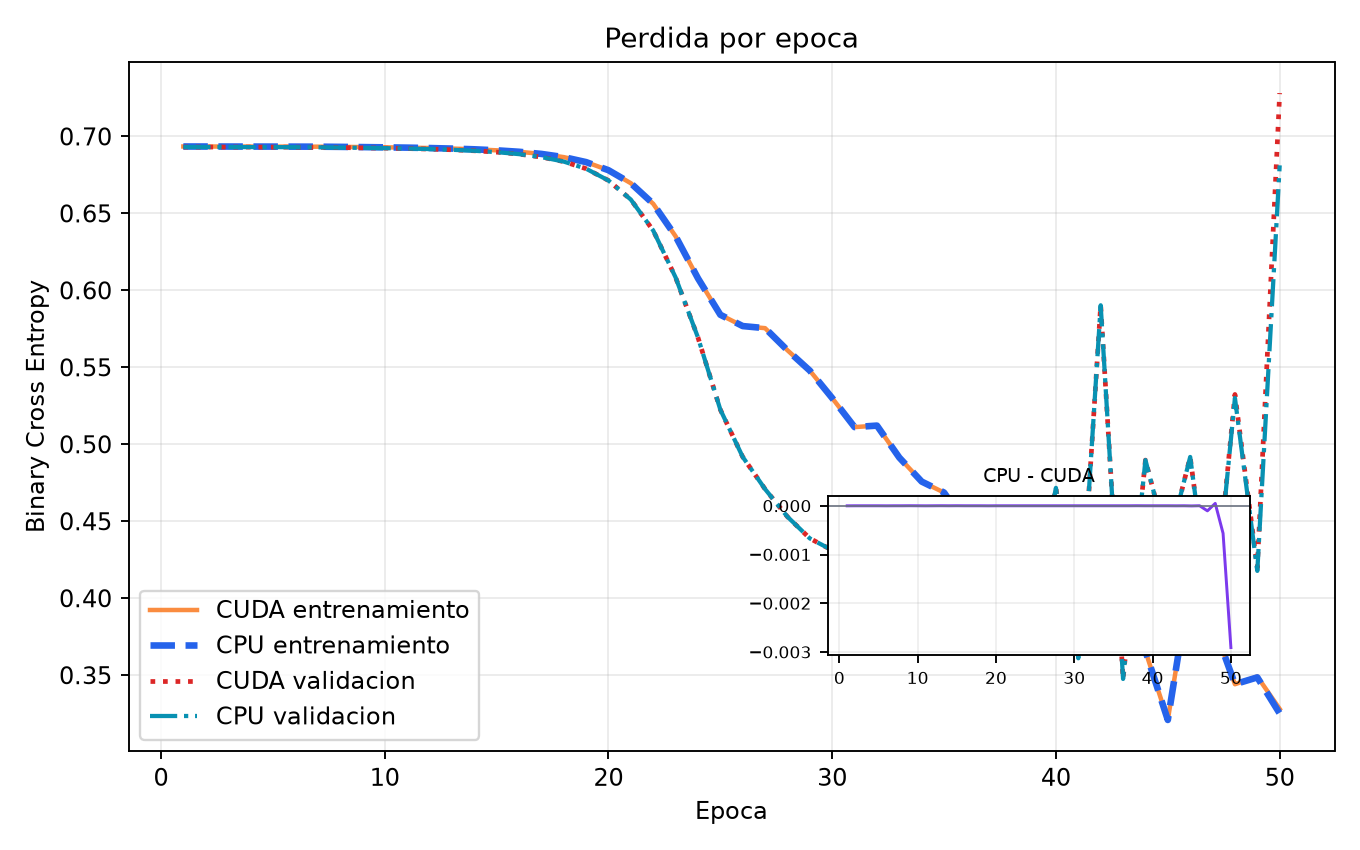

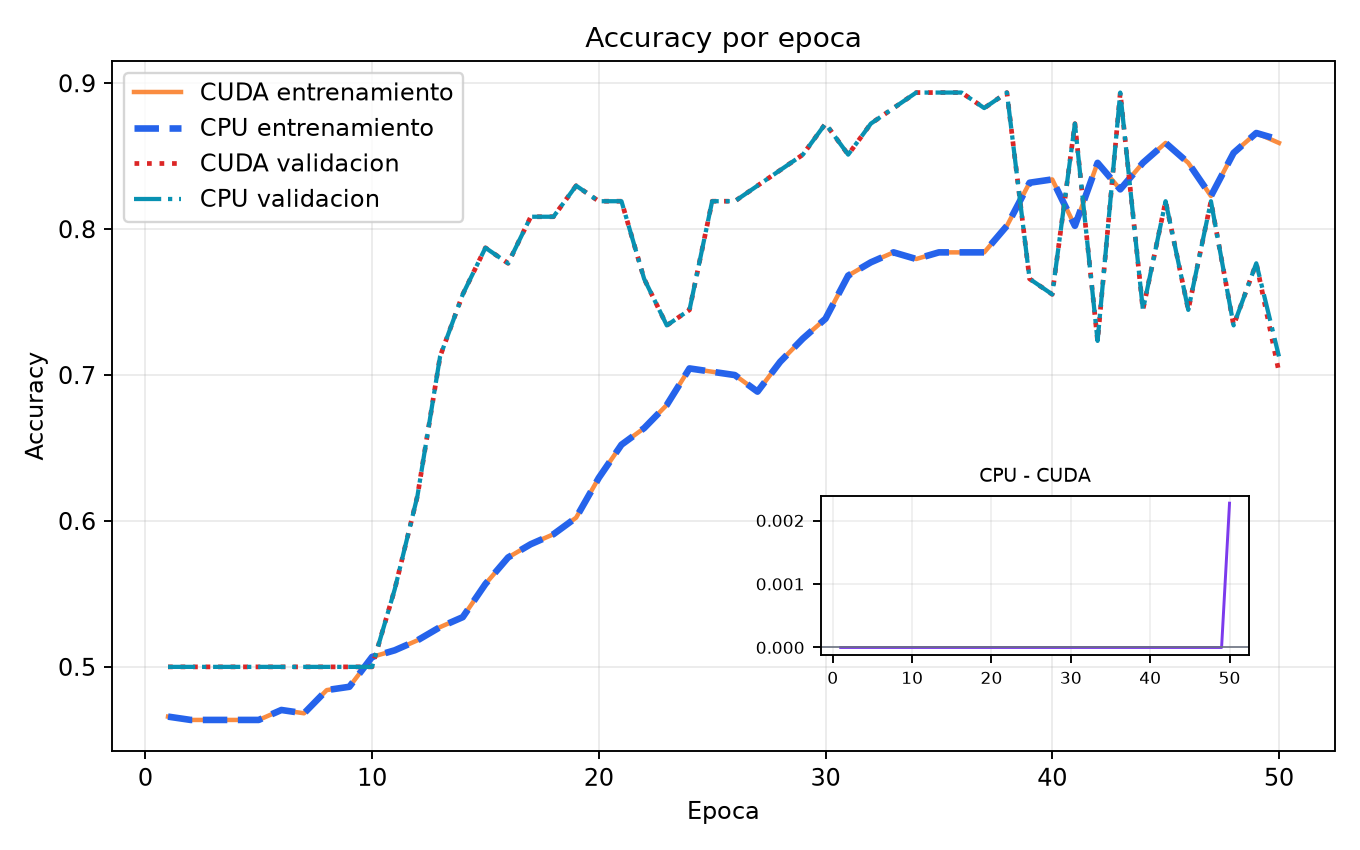

In [4]:
for filename in ["loss.png", "accuracy.png"]:
    chart = metrics_dir / filename
    if chart.exists():
        display(Image(filename=str(chart)))
    else:
        print(f"No existe {filename}.")


## Bloque 5: revisar pesos finales del modelo

El modelo usado por Streamlit se guarda como `models/cuda_weights.bin`. Este bloque confirma si existe. Si no existe, la aplicacion no puede predecir con el modelo CUDA exportado.


In [5]:
weights_path = ROOT / "models" / "cuda_weights.bin"
if weights_path.exists():
    print("Pesos CUDA encontrados:", weights_path.relative_to(ROOT))
    print("Tamano en KB:", round(weights_path.stat().st_size / 1024, 2))
else:
    print("No existen pesos CUDA. Ejecuta manualmente: python -m src.train")


Pesos CUDA encontrados: models/cuda_weights.bin
Tamano en KB: 1032.52


## Bloque 6: conclusion de validacion

Este bloque deja una guia corta para interpretar los resultados. No calcula nada nuevo, pero resume que senales buscar antes de aceptar el modelo final.


In [6]:
print("Senales positivas:")
print("- val_loss baja o se mantiene estable.")
print("- val_accuracy mejora sin oscilar demasiado.")
print("- La diferencia entre entrenamiento y validacion no es excesiva.")
print("\nSenales de alerta:")
print("- loss de entrenamiento baja, pero val_loss sube.")
print("- accuracy de entrenamiento sube mucho y val_accuracy cae.")
print("- Muchas oscilaciones pueden indicar dataset pequeno o ejemplos dificiles.")


Senales positivas:
- val_loss baja o se mantiene estable.
- val_accuracy mejora sin oscilar demasiado.
- La diferencia entre entrenamiento y validacion no es excesiva.

Senales de alerta:
- loss de entrenamiento baja, pero val_loss sube.
- accuracy de entrenamiento sube mucho y val_accuracy cae.
- Muchas oscilaciones pueden indicar dataset pequeno o ejemplos dificiles.
